# Recipe Recommender: Time-Aware Collaborative Filtering

Rating prediction on 1.1M Food.com interactions (231K recipes). Models progress from simple baselines to time-aware matrix factorization that explicitly captures 18 years of rating drift.

**Dataset:** `RAW_recipes.csv` + `RAW_interactions.csv` (Food.com)  
**Split:** 70% train / 15% val / 15% test (seed 42)  
**Zero ratings dropped:** ambiguous in Food.com — a rating of 0 means no explicit rating was given, not a 1-star review  
**Metric:** RMSE

| Model | Test RMSE |
|-------|-----------|
| Recipe mean baseline | ~1.24 |
| Linear regression (recipe features) | ~1.18 |
| TF-IDF Ridge (ingredients) | ~1.17 |
| Static MF (SGD) | ~0.73 |
| **Time-aware MF (SGD)** | **0.69** |

## 1. Data Loading & Preprocessing

In [ ]:
import sys, os
# Ensure src/ package is importable when notebook runs from repo root
_repo_root = os.path.abspath('.')
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)


In [ ]:
import scipy.optimize
import string
from sklearn import linear_model
import gzip
import os
import ast
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
from scipy.sparse import vstack, csr_matrix
from copy import deepcopy
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

In [2]:
# Load all the data

RECIPES_PATH = 'data/dataset/RAW_recipes.csv'
INTERACTIONS_PATH = 'data/dataset/RAW_interactions.csv'

df_raw_recipes = pd.read_csv(RECIPES_PATH)
df_interactions = pd.read_csv(INTERACTIONS_PATH)

print('Checking Raw Recipes')
display(df_raw_recipes.head(3))
print('Raw Recipes Columns:')
display(df_raw_recipes.columns)

print('\nChecking Raw Interactions')
display(df_interactions.head(3))
print('Raw Interactions Columns:')
display(df_interactions.columns)

Checking Raw Recipes


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


Raw Recipes Columns:


Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='object')


Checking Raw Interactions


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...


Raw Interactions Columns:


Index(['user_id', 'recipe_id', 'date', 'rating', 'review'], dtype='object')

In [3]:
# Checking Missing Values

print('For RAW recipes:')
print(df_raw_recipes.isnull().sum()[lambda s: s>0].sort_values(ascending = False))
print('For RAW interactions:')
print(df_interactions.isnull().sum()[lambda s: s>0].sort_values(ascending = False))

For RAW recipes:
description    4979
name              1
dtype: int64
For RAW interactions:
review    169
dtype: int64


In [4]:
# Distribution of ratings in interactions

if 'rating' in df_interactions.columns:
    print('Rating value counts(interactions):')
    print(df_interactions['rating'].value_counts(dropna=False).sort_index())

Rating value counts(interactions):
rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64


In [6]:
# Adding Nutrition to the dataset

print("Starting df_raw_recipes shape:", df_raw_recipes.shape)

def split_nutrition(s):
    p = str(s).strip("[]").split(",")
    p = [q.strip() for q in p]

    if len(p) < 7:
        p = p + [None]*(7-len(p))
    return p[:7]

nut_cols = ['calories', 'total fat (PDV)', 'sugar (PDV)', 'Sodium (PDV)',
            'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']


if 'nutrition' in df_raw_recipes.columns:
    nut_df = df_raw_recipes['nutrition'].apply(split_nutrition).apply(pd.Series)
    nut_df.columns = nut_cols

    for c in nut_cols:
        nut_df[c] = nut_df[c].astype(str).str.replace(r"[\[\]]", "", regex=True).replace({None:'nan'})
        nut_df[c] = pd.to_numeric(nut_df[c], errors='coerce')

    df_raw_recipes = pd.concat([df_raw_recipes, nut_df], axis=1)
                                                                                          
                                                                                          
drop_cols = ['description','submitted','tags','steps','contributor_id']
for c in drop_cols:
    if c in df_raw_recipes.columns:
        df_raw_recipes.drop(columns=[c], inplace=True, errors='ignore')

print("After cleaning df_raw_recipes shape:", df_raw_recipes.shape)
print("Missing counts (top 10):")
print(df_raw_recipes.isnull().sum().sort_values(ascending=False).head(20))
display(df_raw_recipes.head(3))
display(df_raw_recipes[nut_cols].describe())
display(nut_df.head(3))
                                                                                           

Starting df_raw_recipes shape: (231637, 12)
After cleaning df_raw_recipes shape: (231637, 14)
Missing counts (top 10):
name                   1
id                     0
minutes                0
nutrition              0
n_steps                0
ingredients            0
n_ingredients          0
calories               0
total fat (PDV)        0
sugar (PDV)            0
Sodium (PDV)           0
protein (PDV)          0
saturated fat (PDV)    0
carbohydrates (PDV)    0
dtype: int64


,name,id,minutes,nutrition,n_steps,ingredients,n_ingredients,calories,total fat (PDV),sugar (PDV),Sodium (PDV),protein (PDV),saturated fat (PDV),carbohydrates (PDV)
0,arriba baked winter squash mexican style,137739,55,"[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['winter squash', 'mexican seasoning', 'mixed ...",7,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,a bit different breakfast pizza,31490,30,"[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['prepared pizza crust', 'sausage patty', 'egg...",6,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,all in the kitchen chili,112140,130,"[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['ground beef', 'yellow onions', 'diced tomato...",13,269.8,22.0,32.0,48.0,39.0,27.0,5.0


,calories,total fat (PDV),sugar (PDV),Sodium (PDV),protein (PDV),saturated fat (PDV),carbohydrates (PDV)
count,231637.000000,231637.00000,231637.000000,231637.000000,231637.00000,231637.000000,231637.000000
mean,473.942425,36.08070,84.296865,30.147485,34.68186,45.589150,15.560403
std,1189.711374,77.79884,800.080897,131.961589,58.47248,98.235758,81.824560
min,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,174.400000,8.00000,9.000000,5.000000,7.00000,7.000000,4.000000
50%,313.400000,20.00000,25.000000,14.000000,18.00000,23.000000,9.000000
75%,519.700000,41.00000,68.000000,33.000000,51.00000,52.000000,16.000000
max,434360.200000,17183.00000,362729.000000,29338.000000,6552.00000,10395.000000,36098.000000


,calories,total fat (PDV),sugar (PDV),Sodium (PDV),protein (PDV),saturated fat (PDV),carbohydrates (PDV)
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0


In [7]:
# Merging relevant columns into a new df

print("Starting df_interactions shape:", df_interactions.shape)

merge_cols = ['id', 'name', 'ingredients', 'minutes', 'n_ingredients', 'n_steps']

df_merged = df_interactions.merge(df_raw_recipes[merge_cols], left_on='recipe_id', right_on='id', how='left')

display(df_merged.columns)
display(df_merged.shape)
display(df_merged.head(5))


Starting df_interactions shape: (1132367, 5)


Index(['user_id', 'recipe_id', 'date', 'rating', 'review', 'id', 'name',
       'ingredients', 'minutes', 'n_ingredients', 'n_steps'],
      dtype='object')

(1132367, 11)

,user_id,recipe_id,date,rating,review,id,name,ingredients,minutes,n_ingredients,n_steps
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,40893,white bean green chile pepper soup,"['great northern beans', 'yellow onion', 'dice...",495,9,4
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",40893,white bean green chile pepper soup,"['great northern beans', 'yellow onion', 'dice...",495,9,4
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,44394,devilicious cookie cake delights,"[""devil's food cake mix"", 'vegetable oil', 'eg...",20,4,5
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,85009,baked potato toppings,"['mayonnaise', 'salsa', 'cheddar cheese', 'ref...",10,13,3
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",85009,baked potato toppings,"['mayonnaise', 'salsa', 'cheddar cheese', 'ref...",10,13,3


In [8]:
# Parsing Dates to datetime format
if 'date' in df_merged.columns:
    df_merged['__time'] = pd.to_datetime(df_merged['date'], errors='coerce')
    null_dates = df_merged['__time'].isna().sum()
    print('Parsed Date -> __time; null/failed parses:', null_dates)
else:
    df_merged['__time'] = pd.NaT
    print('No date column found in interactions')

Parsed Date -> __time; null/failed parses: 0


In [9]:
def zero_mode(df_interactions, mode='keep'):
    if mode.lower() == 'keep':
        return df_interactions.copy()
    elif mode.lower() == 'drop':
        return df_interactions[df_interactions['rating'] != 0].reset_index(drop=True)
    else:
        raise ValueError("Wrong Input (KEEP, DROP)")

mode = 'drop'
df_mode = zero_mode(df_interactions, mode)
print(f"Zero handling mode: {mode}. Interactions rows: {len(df_mode)}. Zero count: {(df_mode['rating']==0).sum()}")


Zero handling mode: keep. Interactions rows: 1132367. Zero count: 60847


In [10]:
SEED = 42
train_split = 0.7
test_split = 0.15
val_split = 0.15

np.random.seed(SEED)
shuffled_idx = np.random.permutation(len(df_mode))
n = len(df_mode)
n_train = int(n*train_split)
n_test = int(n*test_split)
n_val = int(n*val_split)
train_idx = shuffled_idx[:n_train]
val_idx = shuffled_idx[n_train:n_train+n_val]
test_idx = shuffled_idx[n_train+n_val:]

train_df = df_mode.iloc[train_idx].reset_index(drop=True)
val_df = df_mode.iloc[val_idx].reset_index(drop=True)
test_df = df_mode.iloc[test_idx].reset_index(drop=True)

print("Split sizes - train, val, test:", len(train_df), len(val_df), len(test_df))

def print_rating_stats(df, name):
    vc = df['rating'].value_counts().sort_index()
    print(f"--- {name}: ({len(df)} rows) ---")
    print(vc.to_string())
    print("mean:", df['rating'].mean(), "median:", df['rating'].median())
    print()

print_rating_stats(train_df, 'TRAIN')
print_rating_stats(val_df, 'VAL')
print_rating_stats(test_df, 'TEST')


Split sizes - train, val, test: 792656 169855 169856
--- TRAIN: (792656 rows) ---
rating
0     42676
1      9035
2      9962
3     28685
4    131262
5    571036
mean: 4.409532003794837 median: 5.0

--- VAL: (169855 rows) ---
rating
0      9154
1      1889
2      2037
3      6083
4     28154
5    122538
mean: 4.412693179476612 median: 5.0

--- TEST: (169856 rows) ---
rating
0      9017
1      1894
2      2124
3      6087
4     27944
5    122790
mean: 4.416264365109269 median: 5.0



### Exploratory Data Analysis

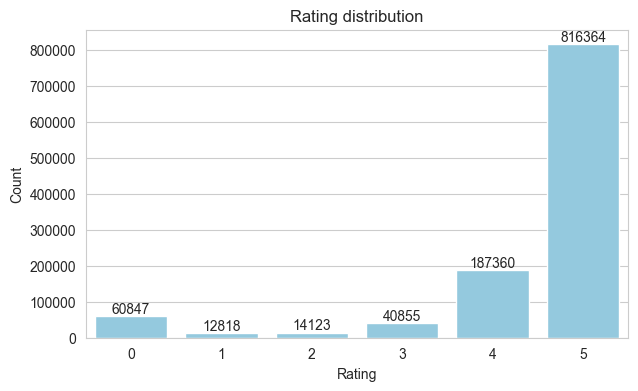

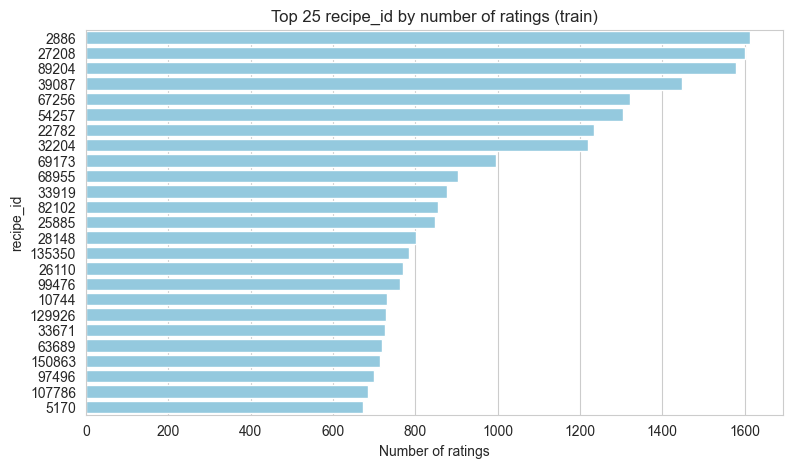

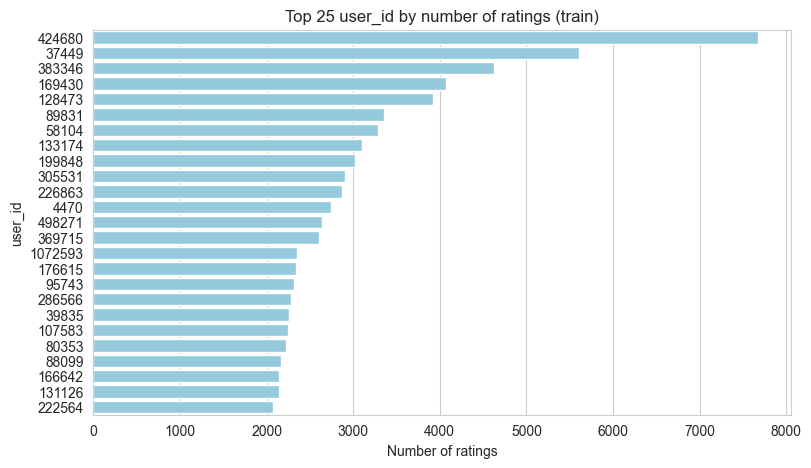

In [11]:
def plot_rating_count(train_df):
    plt.figure(figsize=(7, 4))
    order = sorted(train_df['rating'].dropna().unique())
    
    # Create the countplot
    ax = sns.countplot(x=train_df['rating'].astype(int), order=order, color='skyblue')
    plt.title('Rating distribution')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    
    # Adding value labels on top of each bar
    for p in ax.patches:  # Loop through each bar (patch) in the plot
        ax.annotate(f'{int(p.get_height())}',  # Text to display - count of each bar
                    (p.get_x() + p.get_width() / 2., p.get_height()),  # Position of the text
                    ha='center',  # Horizontal alignment
                    va='bottom')  # Vertical alignment (above the bar)
    
    plt.show()


def plot_top_counts(df, col, topk=25):
    vc = df[col].value_counts().head(topk)
    
    plt.figure(figsize=(9, 5))
    bar_plot = sns.barplot(x=vc.values, y=vc.index.astype(str), color='skyblue')
    plt.title(f'Top {topk} {col} by number of ratings (train)')
    plt.xlabel('Number of ratings')
    plt.ylabel(col)
    plt.show()

# Usage
plot_rating_count(df_interactions)
plot_top_counts(df_interactions, 'recipe_id', topk=25)
plot_top_counts(df_interactions, 'user_id', topk=25)


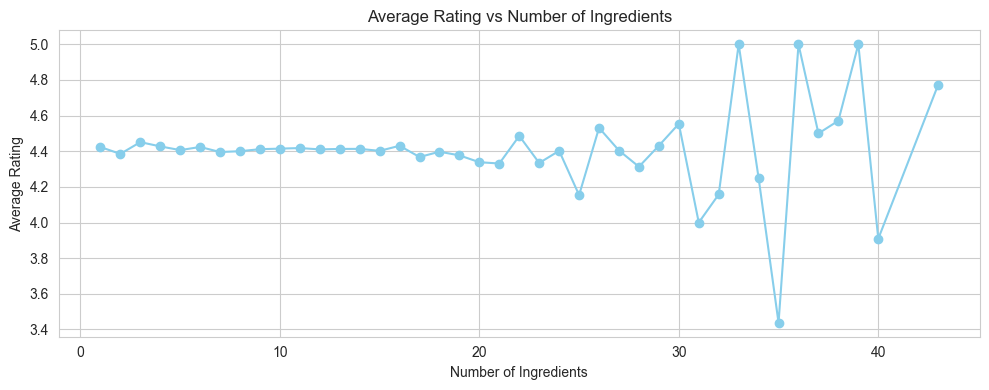

In [12]:
merged_ing = df_interactions.merge(
    df_raw_recipes[['id','n_ingredients']], 
    left_on='recipe_id', right_on='id', how='left'
)

# Cap at 25 ingredients to avoid long-tail spikes
merged_ing['n_ing_capped'] = merged_ing['n_ingredients'].clip(upper=100)

# Compute avg rating per ingredient count
ing_stats = (
    merged_ing.groupby('n_ing_capped')['rating']
    .mean()
    .reset_index()
    .sort_values('n_ing_capped')
)

plt.figure(figsize=(10,4))
plt.plot(ing_stats['n_ing_capped'], ing_stats['rating'], marker='o', color='skyblue')
plt.title('Average Rating vs Number of Ingredients')
plt.xlabel('Number of Ingredients')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

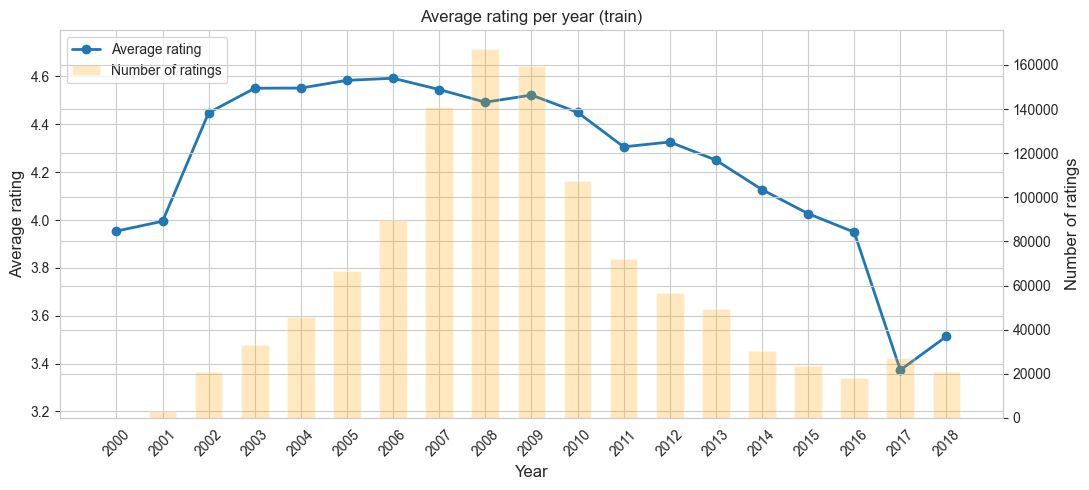

In [13]:
df_year = df_interactions.copy()
if '__time' not in df_year.columns or df_year['__time'].isna().all():
    df_year['__time'] = pd.to_datetime(df_year['date'], errors='coerce')

df_year['year'] = pd.to_datetime(df_year['__time'], errors='coerce').dt.year
by_year = (
    df_year.dropna(subset=['year'])
           .groupby('year')
           .agg(avg_rating=('rating','mean'), count=('rating','count'))
           .reset_index()
           .sort_values('year')
)


years = by_year['year'].astype(int).values
avg = by_year['avg_rating'].values
cnt = by_year['count'].values
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(x, avg, marker='o', linewidth=2, label='Average rating')
ax.set_ylabel('Average rating', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Average rating per year (train)')

y_min = max(0.5, avg.min() - 0.2)
y_max = min(5.0, avg.max() + 0.2)
ax.set_ylim(y_min, y_max)
max_labels = 20
step = max(1, int(np.ceil(len(years) / max_labels)))
xticks_pos = x[::step]
xticks_labels = years[::step]
ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_labels, rotation=45)

# secondary axis for counts (bar)
ax2 = ax.twinx()
width = 0.6
ax2.bar(x, cnt, alpha=0.25, width=width, color='orange', label='Number of ratings')
ax2.set_ylabel('Number of ratings', fontsize=12)
max_cnt = cnt.max()
ax2.set_ylim(0, max_cnt * 1.05)
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

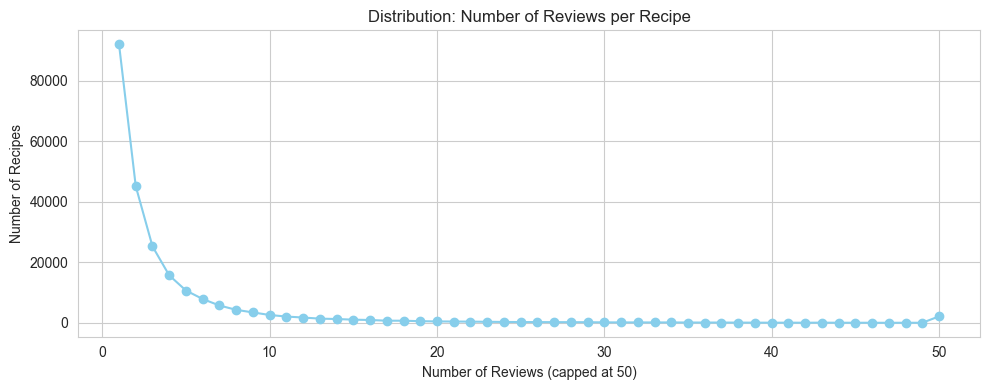

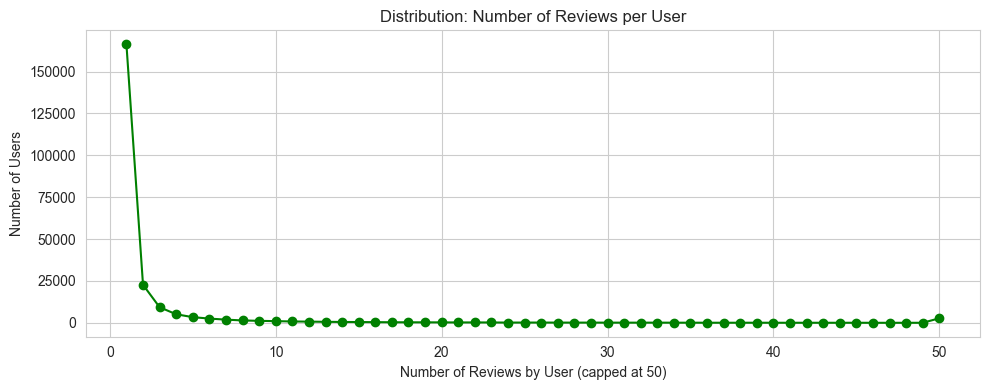

In [14]:

reviews_per_recipe = df_interactions.groupby('recipe_id').size()

# Bin counts (1 review, 2 reviews, ..., cap at 50)
max_bin = 50
counts = reviews_per_recipe.clip(upper=max_bin)

freq = counts.value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(freq.index, freq.values, marker='o', color='skyblue')
plt.title('Distribution: Number of Reviews per Recipe')
plt.xlabel('Number of Reviews (capped at 50)')
plt.ylabel('Number of Recipes')
plt.grid(True)
plt.tight_layout()
plt.show()


reviews_per_user = df_interactions.groupby('user_id').size()

# Bin + cap at 50 again
counts_u = reviews_per_user.clip(upper=max_bin)

freq_u = counts_u.value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(freq_u.index, freq_u.values, marker='o', color='green')
plt.title('Distribution: Number of Reviews per User')
plt.xlabel('Number of Reviews by User (capped at 50)')
plt.ylabel('Number of Users')
plt.grid(True)
plt.tight_layout()
plt.show()



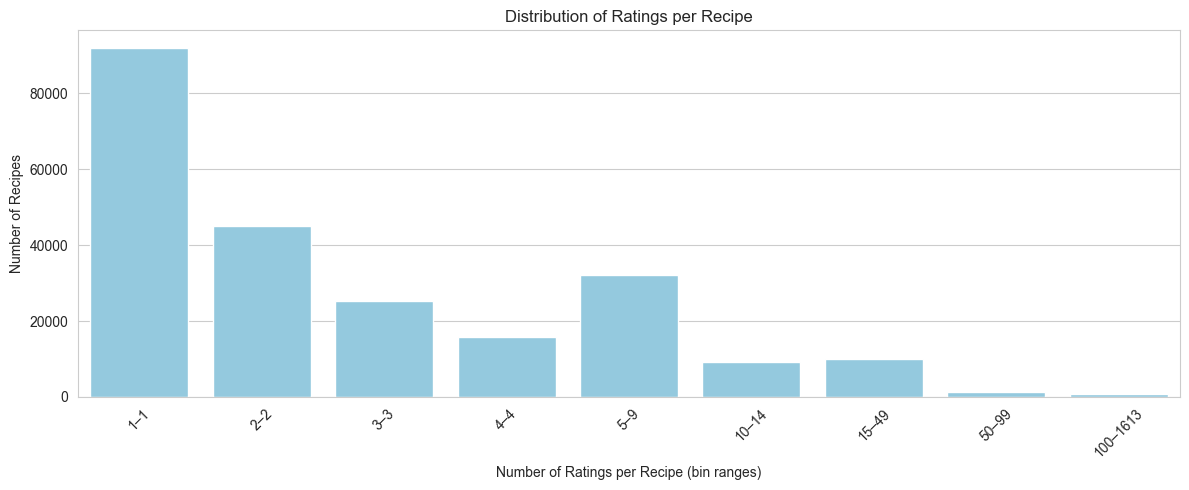

In [15]:
# Helper: get recipe name map (falls back to id string if name missing)
id2name = {}
if 'id' in df_raw_recipes.columns and 'name' in df_raw_recipes.columns:
    id2name = dict(zip(df_raw_recipes['id'], df_raw_recipes['name']))

# Ratings per recipe (binned)
# Use recipe_id counts (safer than name-based grouping)
ratings_per_recipe = df_interactions.groupby('recipe_id')['rating'].count()

# Define bins (ensure last bin edge is integer)
max_val = int(ratings_per_recipe.max())
bin_edges = [1,2,3,4,5,10,15,50,100, max_val+1]  # +1 so histogram upper bound inclusive

counts, edges = np.histogram(ratings_per_recipe, bins=bin_edges)

# Create readable labels (use ints)
bin_labels = [f'{int(edges[i])}–{int(edges[i+1])-1}' for i in range(len(edges)-1)]

plt.figure(figsize=(12,5))
sns.barplot(x=bin_labels, y=counts, color='skyblue')
plt.xlabel("Number of Ratings per Recipe (bin ranges)")
plt.ylabel("Number of Recipes")
plt.title("Distribution of Ratings per Recipe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

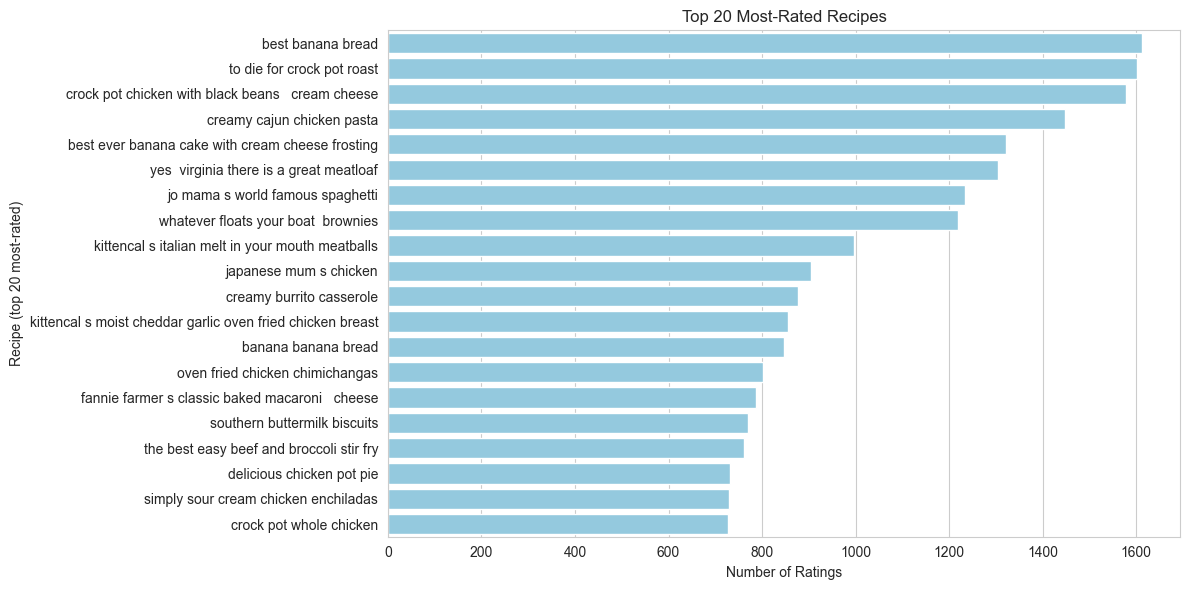

In [16]:
top20 = ratings_per_recipe.nlargest(20)
top20_names = [id2name.get(rid, str(rid)) for rid in top20.index]

plt.figure(figsize=(12,6))
sns.barplot(x=top20.values, y=top20_names, color='skyblue')
plt.xlabel("Number of Ratings")
plt.ylabel("Recipe (top 20 most-rated)")
plt.title("Top 20 Most-Rated Recipes")
plt.tight_layout()
plt.show()


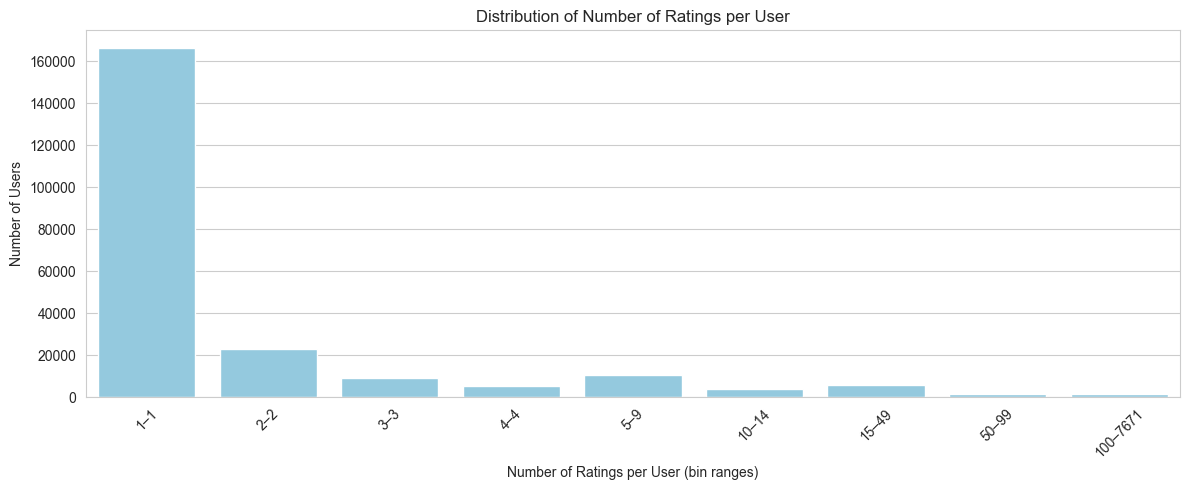

In [17]:
# Ratings per user (binned)

ratings_per_user = df_interactions.groupby('user_id')['rating'].count()
max_val_user = int(ratings_per_user.max())
bin_edges_user = [1,2,3,4,5,10,15,50,100, max_val_user+1]

counts_u, edges_u = np.histogram(ratings_per_user, bins=bin_edges_user)
bin_labels_u = [f'{int(edges_u[i])}–{int(edges_u[i+1])-1}' for i in range(len(edges_u)-1)]

plt.figure(figsize=(12,5))
sns.barplot(x=bin_labels_u, y=counts_u, color='skyblue')
plt.xlabel("Number of Ratings per User (bin ranges)")
plt.ylabel("Number of Users")
plt.title("Distribution of Number of Ratings per User")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

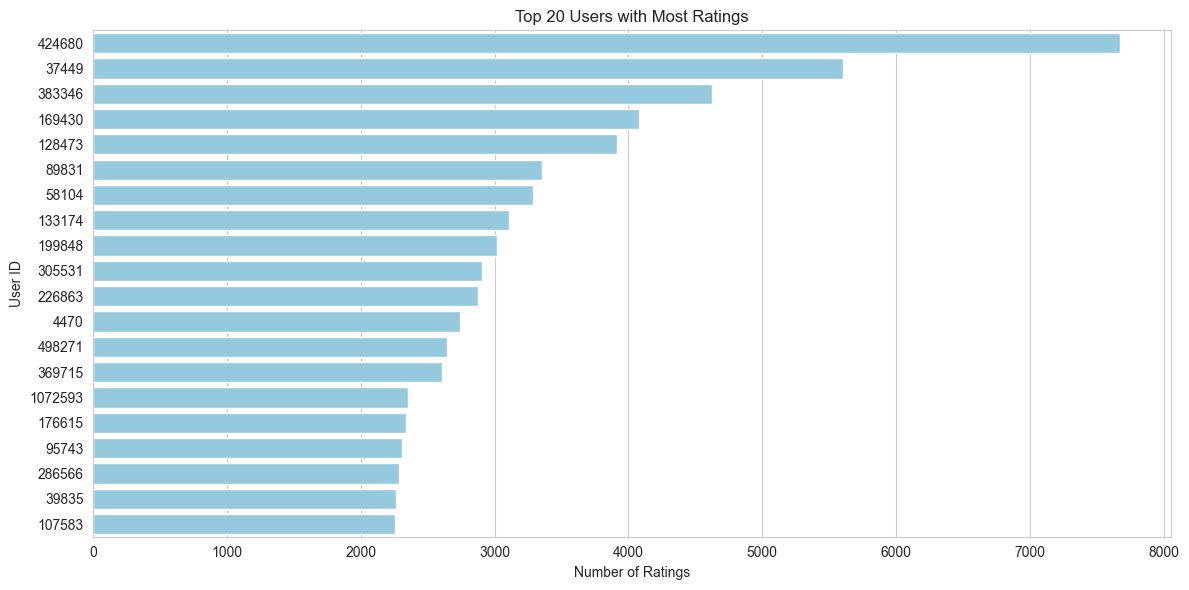

In [18]:
# Top 20 users by number of ratings

top20_users = ratings_per_user.nlargest(20)
plt.figure(figsize=(12,6))
sns.barplot(x=top20_users.values, y=top20_users.index.astype(str), color='skyblue')
plt.xlabel("Number of Ratings")
plt.ylabel("User ID")
plt.title("Top 20 Users with Most Ratings")
plt.tight_layout()
plt.show()

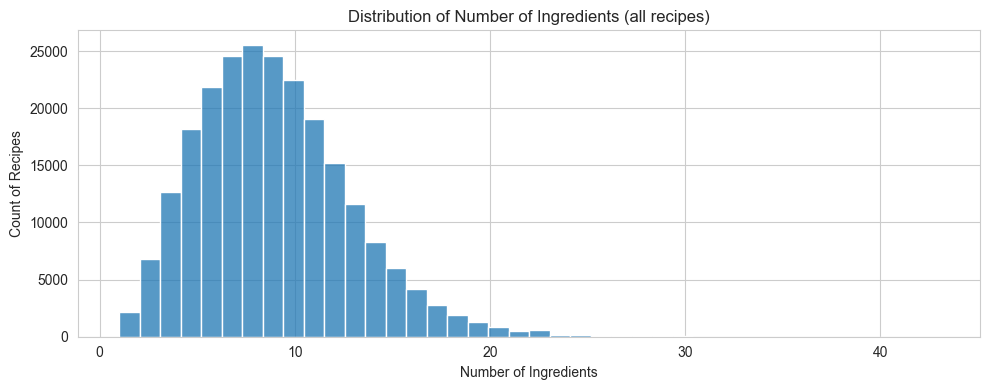

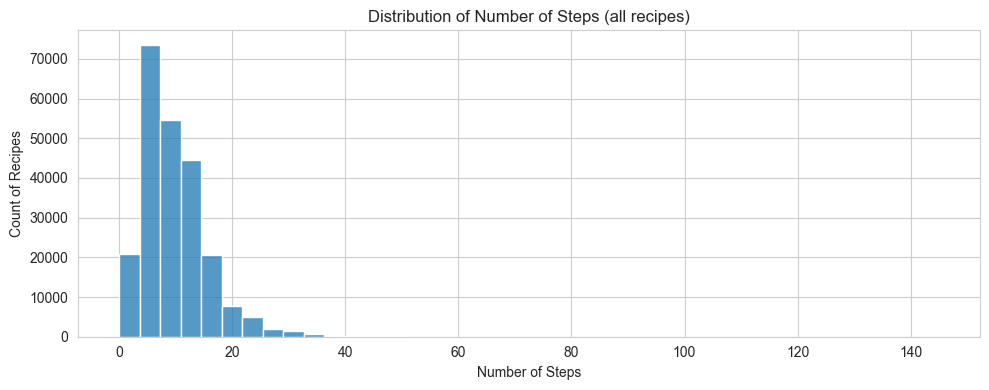

In [19]:
# Histograms for recipe meta: n_ingredients and n_steps

# n_ingredients
if 'n_ingredients' in df_raw_recipes.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df_raw_recipes['n_ingredients'].dropna(), bins=40)
    plt.xlabel('Number of Ingredients')
    plt.ylabel('Count of Recipes')
    plt.title('Distribution of Number of Ingredients (all recipes)')
    plt.tight_layout()
    plt.show()
else:
    print("n_ingredients column not found in df_raw_recipes.")

# n_steps
if 'n_steps' in df_raw_recipes.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df_raw_recipes['n_steps'].dropna(), bins=40)
    plt.xlabel('Number of Steps')
    plt.ylabel('Count of Recipes')
    plt.title('Distribution of Number of Steps (all recipes)')
    plt.tight_layout()
    plt.show()
else:
    print("n_steps column not found in df_raw_recipes.")

## 2. Baseline Models

In [ ]:
# Baseline: recipe mean

# compute recipe means from TRAIN only
recipe_means = train_df.groupby('recipe_id')['rating'].mean()

# global mean from TRAIN
global_mean = train_df['rating'].mean()
print("Global mean (train):", global_mean)

def baseline_predict_rating(recipe_id):
    return recipe_means.get(recipe_id, global_mean)

# validation preds & RMSE
val_preds = val_df['recipe_id'].apply(baseline_predict_rating).values
rmse_val = np.sqrt(mean_squared_error(val_df['rating'].values, val_preds))
print("Baseline (recipe mean) RMSE on VAL:", rmse_val)

# test preds & RMSE
test_preds = test_df['recipe_id'].apply(baseline_predict_rating).values
rmse_test = np.sqrt(mean_squared_error(test_df['rating'].values, test_preds))
print("Baseline (recipe mean) RMSE on TEST:", rmse_test)


### Item-Based Collaborative Filtering

In [21]:
# Item-based collaborative filtering 

# Build ratingsPerUser and ratingsPerItem from TRAIN
ratingsPerUser = defaultdict(list)
ratingsPerItem = defaultdict(list)

for _, row in train_df.iterrows():
    u = row['user_id']
    i = row['recipe_id']
    r = row['rating']
    ratingsPerUser[u].append((i, r))
    ratingsPerItem[i].append((u, r))

# pearson_similarity 
def pearson_similarity(i, j):
    # if either item missing return 0
    if i not in ratingsPerItem or j not in ratingsPerItem:
        return 0.0
    users_i = {u:r for u,r in ratingsPerItem[i]}
    users_j = {u:r for u,r in ratingsPerItem[j]}
    
    # users who rated both
    common = users_i.keys() & users_j.keys()
    if len(common) == 0:
        return 0.0

    ratings_i = [users_i[u] for u in common]
    ratings_j = [users_j[u] for u in common]

    mean_i = sum(ratings_i) / len(ratings_i)
    mean_j = sum(ratings_j) / len(ratings_j)

    diff_i = [r - mean_i for r in ratings_i]
    diff_j = [r - mean_j for r in ratings_j]

    num = sum(di * dj for di, dj in zip(diff_i, diff_j))
    den_i = math.sqrt(sum(di * di for di in diff_i))
    den_j = math.sqrt(sum(dj * dj for dj in diff_j))

    denom = den_i * den_j
    if denom == 0:
        return 0.0

    return num / denom

In [ ]:
# predictor using top-k neighbors
def predict_item_cf(u, i, k=20):
    rated_items = ratingsPerUser.get(u, [])
    sims = []
    for j, r_j in rated_items:
        if j == i:
            continue
        sim = pearson_similarity(i, j)
        if sim > 0:
            sims.append((sim, r_j))
    if not sims:
        return recipe_means.get(i, global_mean)
    # sort by similarity desc, take top-k
    sims = sorted(sims, key=lambda x: x[0], reverse=True)[:k]
    num = sum(sim * r for sim, r in sims)
    den = sum(sim for sim, _ in sims)
    if den == 0:
        return recipe_means.get(i, global_mean)
    return num / den

# Evaluate on validation
val_preds = []
for _, row in val_df.iterrows():
    u = row['user_id']; i = row['recipe_id']
    if u not in ratingsPerUser:
        val_preds.append(global_mean)
    else:
        val_preds.append(predict_item_cf(u, i, k=20))

val_rmse = np.sqrt(mean_squared_error(val_df['rating'].values, np.array(val_preds)))
print("Item-CF RMSE on VAL:", val_rmse)

In [23]:
train_recipes = set(train_df['recipe_id'])
val_recipes = set(val_df['recipe_id'])
test_recipes = set(test_df['recipe_id'])
print("Train ∩ Val:", len(train_recipes & val_recipes))
print("Train ∩ Test:", len(train_recipes & test_recipes))
print("Val ∩ Test:", len(val_recipes & test_recipes))

Train ∩ Val: 66243
Train ∩ Test: 66121
Val ∩ Test: 38661


In [ ]:
test_preds = []
for _, row in test_df.iterrows():
    u = row['user_id']; i = row['recipe_id']
    if u not in ratingsPerUser:
        test_preds.append(global_mean)
    else:
        test_preds.append(predict_item_cf(u, i, k=20))

test_rmse = np.sqrt(mean_squared_error(test_df['rating'].values, np.array(test_preds)))
print("Item-CF RMSE on TEST:", test_rmse)

### Regression Models

In [ ]:
# Simple regression using recipe numeric features

# prepare recipe features from df_raw_recipes
recipe_features = df_raw_recipes[['id','minutes','n_steps','n_ingredients']].copy()

# Fill missing sensibly 
recipe_features['minutes'] = recipe_features['minutes'].fillna(recipe_features['minutes'].median())
recipe_features['n_steps'] = recipe_features['n_steps'].fillna(0)
recipe_features['n_ingredients'] = recipe_features['n_ingredients'].fillna(0)

# Merge into splits
train_feat = train_df.merge(recipe_features, left_on='recipe_id', right_on='id', how='left')
val_feat = val_df.merge(recipe_features, left_on='recipe_id', right_on='id', how='left')
test_feat = test_df.merge(recipe_features, left_on='recipe_id', right_on='id', how='left')

feature_cols = ['minutes', 'n_steps', 'n_ingredients']
X_train = train_feat[feature_cols].fillna(0)
y_train = train_feat['rating']
X_val = val_feat[feature_cols].fillna(0)
y_val = val_feat['rating']

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_val = lr.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
print("Linear regression RMSE on VAL:", rmse_val)

# Optionally test set
X_test = test_feat[feature_cols].fillna(0)
y_test = test_feat['rating']
pred_test = lr.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
print("Linear regression RMSE on TEST:", rmse_test)

In [25]:
# TF-IDF ingredients -> Ridge regression 

# prepare ingredients strings
if 'ingredients_str' not in df_raw_recipes.columns:
    df_raw_recipes['ingredients_list'] = df_raw_recipes['ingredients'].apply(ast.literal_eval)
    df_raw_recipes['ingredients_str'] = df_raw_recipes['ingredients_list'].apply(lambda lst: " ".join(lst))

# fit TF-IDF on all recipes
tfidf = TfidfVectorizer(min_df=5, max_df=0.9)
X_ing = tfidf.fit_transform(df_raw_recipes['ingredients_str'].fillna(""))

# recipe_id -> positional index mapping
recipe_to_idx = {int(rid): int(pos) for pos, rid in zip(df_raw_recipes.index, df_raw_recipes['id'])}

# safe index lists for splits
def safe_indices(series_recipe_ids):
    idxs = []
    for rid in series_recipe_ids:
        pos = recipe_to_idx.get(int(rid), None)
        idxs.append(pos)
    return idxs

In [26]:
tfidf_train_idx = safe_indices(train_df['recipe_id'])
tfidf_val_idx = safe_indices(val_df['recipe_id'])
tfidf_test_idx = safe_indices(test_df['recipe_id'])

# masks for which rows have a valid TF-IDF row
train_mask = np.array([i is not None for i in tfidf_train_idx])
val_mask = np.array([i is not None for i in tfidf_val_idx])
test_mask = np.array([i is not None for i in tfidf_test_idx])

# Build sparse X_train/X_val selecting only valid indices; fallback recipes handled at prediction
X_train = X_ing[[i for i in tfidf_train_idx if i is not None]]
X_val   = X_ing[[i for i in tfidf_val_idx if i is not None]]
X_test  = X_ing[[i for i in tfidf_test_idx if i is not None]]

y_train = train_df['rating'].values[train_mask]
y_val = val_df['rating'].values[val_mask]
y_test = test_df['rating'].values[test_mask]

In [ ]:
# train Ridge on sparse TF-IDF
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Precompute regularized item mean
global_mean = train_df['rating'].mean()
alpha = 25.0
reg_grp = train_df.groupby('recipe_id')['rating'].agg(['sum','count']).reset_index().set_index('recipe_id')
reg_grp['reg_mean'] = (reg_grp['sum'] + global_mean * alpha) / (reg_grp['count'] + alpha)

# Predict on validation (use fallback for recipes missing in TF-IDF)
val_preds = []
for idx, rid in zip(tfidf_val_idx, val_df['recipe_id']):
    if idx is None:
        val_preds.append(reg_grp['reg_mean'].get(rid, global_mean))
    else:
        val_preds.append(float(ridge.predict(X_ing[idx:idx+1])[0]))
val_rmse = np.sqrt(mean_squared_error(val_df['rating'].values, np.array(val_preds)))
print("TF-IDF Ridge val RMSE:", round(val_rmse, 4))

In [ ]:
# Predict on test
test_preds = []
for idx, rid in zip(tfidf_test_idx, test_df['recipe_id']):
    if idx is None:
        test_preds.append(reg_grp['reg_mean'].get(rid, global_mean))
    else:
        test_preds.append(float(ridge.predict(X_ing[idx:idx+1])[0]))

# Compute overall test RMSE across all test_df rows:
test_preds_full = []
for rid in test_df['recipe_id']:
    pos = recipe_to_idx.get(int(rid), None)
    if pos is None:
        test_preds_full.append(reg_grp['reg_mean'].get(rid, global_mean))
    else:
        test_preds_full.append(float(ridge.predict(X_ing[pos:pos+1])[0]))

test_rmse_full = np.sqrt(mean_squared_error(test_df['rating'].values, np.array(test_preds_full)))
print("TF-IDF Ridge test RMSE:", round(test_rmse_full, 4))

### User Profile TF-IDF (Cosine Similarity)

In [29]:
# Personalized TF-IDF user profiles -> cosine similarity to item vectors

# Build helper: get sparse item vector by recipe_id
def get_item_vec_sparse(recipe_id):
    pos = recipe_to_idx.get(int(recipe_id), None)
    if pos is None:
        return None
    return X_ing[pos]  

# Build ratingsPerUser from TRAIN 
ratingsPerUser = defaultdict(list)
for u,i,r in zip(train_df['user_id'], train_df['recipe_id'], train_df['rating']):
    ratingsPerUser[u].append((i,r))

# Build user profiles as weighted sum of item TF-IDF rows and normalize
user_profiles = {}
count = 0
for u, items in ratingsPerUser.items():
    vecs = []
    weights = []
    for rid, rating in items:
        item_vec = get_item_vec_sparse(rid)
        if item_vec is not None:
            vecs.append(item_vec)
            weights.append(rating - global_mean)
    if len(vecs) == 0:
        continue
    M = vstack(vecs)
    w = np.array(weights).reshape(1, -1)
    w_sparse = csr_matrix(w)
    user_vec_sparse = w_sparse.dot(M)
    user_vec = user_vec_sparse.toarray().reshape(-1)
    norm = np.linalg.norm(user_vec)
    if norm > 0:
        user_profiles[u] = (user_vec / norm).astype(np.float32)
    count += 1

print("Total user profiles built:", len(user_profiles))

Total user profiles built: 174360


In [ ]:
# Prediction function: cosine similarity between user profile and item vector
def predict_user_profile(u, rid):
    if u not in user_profiles:
        return global_mean
    item_vec_sparse = get_item_vec_sparse(rid)
    if item_vec_sparse is None:
        return global_mean
    item_vec = item_vec_sparse.toarray().reshape(-1)
    iv_norm = np.linalg.norm(item_vec)
    if iv_norm == 0:
        return global_mean
    item_vec = item_vec / iv_norm
    sim = float(np.dot(user_profiles[u], item_vec))
    pred = 1 + 4 * ((sim + 1) / 2)
    return float(np.clip(pred, 1.0, 5.0))

# Evaluate on validation
full_preds = [predict_user_profile(u, rid) for u,rid in zip(val_df['user_id'], val_df['recipe_id'])]
full_rmse = np.sqrt(mean_squared_error(val_df['rating'].values, np.array(full_preds)))
print("User-profile TF-IDF val RMSE:", round(full_rmse,4))

### Static Matrix Factorization (SGD)

In [35]:
# Prepare rating lists and maps
ratingsTrain = list(zip(train_df['user_id'], train_df['recipe_id'], train_df['rating']))
ratingsValid = list(zip(val_df['user_id'], val_df['recipe_id'], val_df['rating']))

ratingsPerUser = defaultdict(list)
ratingsPerItem = defaultdict(list)
for u,i,r in ratingsTrain:
    ratingsPerUser[u].append((i,r))
    ratingsPerItem[i].append((u,r))

# global mean 
global_mean = train_df['rating'].mean()

# validation MSE
def validMSE(ratingsValid, alpha, betaU, betaI, P, Q):
    sse = 0.0
    count = 0
    for u, i, r in ratingsValid:
        bu = betaU.get(u, 0.0)
        bi = betaI.get(i, 0.0)
        pu = P.get(u, None)
        qi = Q.get(i, None)
        mf_term = 0.0
        if (pu is not None) and (qi is not None):
            mf_term = float(np.dot(pu, qi))
        pred = alpha + bu + bi + mf_term
        sse += (pred - r) ** 2
        count += 1
    return (sse / count) if count > 0 else float('inf')

In [36]:
# trains P/Q + biases with SGD and returns best model based on val MSE
def goodModel(ratingsTrain, ratingsValid, ratingsPerUser, ratingsPerItem, alpha_init, betaU_init, betaI_init,
              k = 5, lamb = 0.05, epochs = 10, lr = 0.005, patience = 3, seed = 42):
    random.seed(seed)
    np.random.seed(seed)

    # Unique users and items
    users = list(ratingsPerUser.keys())
    items = list(ratingsPerItem.keys())

    # Initialize latent factors 
    P = {u: np.random.normal(0, 0.05, k).astype(np.float32) for u in users}
    Q = {i: np.random.normal(0, 0.05, k).astype(np.float32) for i in items}

    betaU = {u: float(betaU_init.get(u, 0.0)) for u in users}
    betaI = {i: float(betaI_init.get(i, 0.0)) for i in items}
    alpha = float(alpha_init)

    data = list(ratingsTrain)

    best_val = float('inf')
    best_model = None
    wait = 0

    for ep in range(1, epochs+1):
        random.shuffle(data)
        # SGD over all training triples
        for (u_raw, i_raw, r) in data:
            if u_raw not in P or i_raw not in Q:
                continue

            pu = P[u_raw]
            qi = Q[i_raw]
            bu = betaU[u_raw]
            bi = betaI[i_raw]

            pred = alpha + bu + bi + float(np.dot(pu, qi))
            err = r - pred

            # Update biases
            betaU[u_raw] += lr * (err - lamb * bu)
            betaI[i_raw]  += lr * (err - lamb * bi)

            # Update latent factors
            P[u_raw] += lr * (err * qi - lamb * pu)
            Q[i_raw] += lr * (err * pu - lamb * qi)

        # compute average residual on training set (cheap-ish)
        resid_sum = 0.0
        for (u_raw, i_raw, r) in data:
            pu = P.get(u_raw, None)
            qi = Q.get(i_raw, None)
            bu = betaU.get(u_raw, 0.0)
            bi = betaI.get(i_raw, 0.0)
            mf_term = float(np.dot(pu, qi)) if (pu is not None and qi is not None) else 0.0
            resid_sum += (r - (alpha + bu + bi + mf_term))
        alpha += 0.01 * (resid_sum / len(data))

        # Compute training loss (for monitoring)
        train_preds = []
        train_trues = []
        for (u_raw, i_raw, r) in data[:20000]:  # sample for speed of reporting
            pu = P.get(u_raw, None); qi = Q.get(i_raw, None)
            bu = betaU.get(u_raw, 0.0); bi = betaI.get(i_raw, 0.0)
            mf_term = float(np.dot(pu, qi)) if (pu is not None and qi is not None) else 0.0
            train_preds.append(alpha + bu + bi + mf_term)
            train_trues.append(r)
        train_rmse = math.sqrt(mean_squared_error(train_trues, train_preds))

        # Validate
        val_mse = validMSE(ratingsValid, alpha, betaU, betaI, P, Q)
        val_rmse = math.sqrt(val_mse) if val_mse != float('inf') else float('inf')

        print(f"Epoch {ep:2d} | train_rmse(sample)={train_rmse:.4f} | val_rmse={val_rmse:.4f}")

        if val_mse < best_val:
            best_val = val_mse
            best_model = (alpha, deepcopy(betaU), deepcopy(betaI), {u: P[u].copy() for u in P}, {i: Q[i].copy() for i in Q})
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    if best_model is None:
        # If no improvement ever, return current model
        best_model = (alpha, betaU, betaI, P, Q)

    return best_model

In [ ]:
# Tuning wrapper
def tune_model(
    ratingsTrain, ratingsValid, ratingsPerUser, ratingsPerItem,
    lr_list = [0.01], k_list = [5,10,15], lamb_list = [0.01, 0.02, 0.05],
    epochs=10, patience=3
):
    best_mse = float('inf')
    best_cfg = None
    best_model = None

    for lr in lr_list:
        for k in k_list:
            for lamb in lamb_list:
                print(f"\nTrying lr={lr}, k={k}, lambda={lamb}")
                # init biases
                betaU0 = {u: 0.0 for u in ratingsPerUser}
                betaI0 = {i: 0.0 for i in ratingsPerItem}
                alpha0 = global_mean

                model = goodModel(
                    ratingsTrain,
                    ratingsValid,
                    ratingsPerUser,
                    ratingsPerItem,
                    alpha_init=alpha0,
                    betaU_init=betaU0,
                    betaI_init=betaI0,
                    k=k,
                    lamb=lamb,
                    epochs=epochs,
                    lr=lr,
                    patience=patience
                )

                # compute validation mse for returned best model
                alpha_b, bu_b, bi_b, P_b, Q_b = model
                val_mse = validMSE(ratingsValid, alpha_b, bu_b, bi_b, P_b, Q_b)
                val_rmse = math.sqrt(val_mse)
                print(f"Validation RMSE (final) = {val_rmse:.5f}")

                if val_mse < best_mse:
                    best_mse = val_mse
                    best_cfg = (lr, k, lamb)
                    best_model = model

    print("\nBest model config: ")
    print("lr =", best_cfg[0])
    print("k =", best_cfg[1])
    print("lambda =", best_cfg[2])
    print("best validation RMSE:", math.sqrt(best_mse))
    return best_cfg, best_model

# Run a small tune (reduce epochs for speed)
best_cfg, best_model = tune_model(
    ratingsTrain, ratingsValid, ratingsPerUser, ratingsPerItem,
    lr_list=[0.01], k_list=[5,10], lamb_list=[0.01, 0.02],
    epochs=6, patience=2
)

alpha_best, betaU_best, betaI_best, P_best, Q_best = best_model
print("Tuning finished. Best config:", best_cfg)
print("Returned model alpha:", alpha_best)

In [ ]:
# STATIC LATENT FACTOR MODEL TEST EVALUATION

def predict_static_latent(u, i, model_tuple):
    alpha, betaU, betaI, P, Q = model_tuple
    bu = betaU.get(u, 0.0)
    bi = betaI.get(i, 0.0)
    pu = P.get(u, None)
    qi = Q.get(i, None)
    mf_term = float(np.dot(pu, qi)) if (pu is not None and qi is not None) else 0.0
    return float(np.clip(alpha + bu + bi + mf_term, 1.0, 5.0))

# compute test RMSE
test_preds = []
test_trues = []

for _, row in test_df.iterrows():
    u = row['user_id']
    i = row['recipe_id']
    r = row['rating']
    test_trues.append(r)
    test_preds.append(predict_static_latent(u, i, best_model))  # best_model from tuning

static_test_rmse = np.sqrt(mean_squared_error(test_trues, test_preds))
print("\nSTATIC MF: Test RMSE =", static_test_rmse)

## 3. Time-Aware Matrix Factorization

In [41]:
# Time-aware latent factor model (SGD) with user-time and item-time biases

time_mode = 'year'
def extract_time_bin(ts, mode='year'):
    if pd.isna(ts):
        return None
    if mode == 'year':
        return int(ts.year)
    elif mode == 'month':
        return int(ts.year * 100 + ts.month) 
    else:
        raise ValueError("mode must be 'year' or 'month'")

for df in [train_df, val_df, test_df]:
    if '__time' not in df.columns or df['__time'].isna().all():
        df['__time'] = pd.to_datetime(df['date'], errors='coerce')

# Add time_bin column
for df in [train_df, val_df, test_df]:
    df['time_bin'] = df['__time'].apply(lambda t: extract_time_bin(t, time_mode))

# Filter out rows without a valid time bin for this time_mode
train_tt = train_df.dropna(subset=['time_bin']).reset_index(drop=True)
val_tt = val_df.dropna(subset=['time_bin']).reset_index(drop=True)
test_tt = test_df.dropna(subset=['time_bin']).reset_index(drop=True)

# Build rating triples with time
ratingsTrain = list(zip(train_tt['user_id'], train_tt['recipe_id'], train_tt['time_bin'], train_tt['rating']))
ratingsValid = list(zip(val_tt['user_id'], val_tt['recipe_id'], val_tt['time_bin'], val_tt['rating']))

# Build maps used during training
ratingsPerUser = defaultdict(list)
ratingsPerItem = defaultdict(list)
timeBins = set()

for u, i, t, r in ratingsTrain:
    ratingsPerUser[u].append((i, r, t))
    ratingsPerItem[i].append((u, r, t))
    timeBins.add(t)

# Map unique time bins to contiguous indices if needed
time_to_idx = {t: idx for idx, t in enumerate(sorted(timeBins))}
print("Unique time bins:", len(timeBins), "e.g. sample:", list(time_to_idx.items())[:5])

# global mean
global_mean = train_tt['rating'].mean()
print("Global mean (train, time-filtered):", global_mean)

# Validation MSE helper adapted for time-aware model 
def validMSE_time(ratingsValid, alpha, b_u, b_i, b_u_t, b_i_t, P, Q):
    sse = 0.0
    count = 0
    for u, i, t, r in ratingsValid:
        bu = b_u.get(u, 0.0)
        bi = b_i.get(i, 0.0)
        but = b_u_t.get((u,t), 0.0)
        bit = b_i_t.get((i,t), 0.0)
        pu = P.get(u, None)
        qi = Q.get(i, None)
        mf_term = 0.0
        if (pu is not None) and (qi is not None):
            mf_term = float(np.dot(pu, qi))
        pred = alpha + bu + bi + but + bit + mf_term
        sse += (pred - r) ** 2
        count += 1
    return (sse / count) if count > 0 else float('inf')

Unique time bins: 19 e.g. sample: [(2000, 0), (2001, 1), (2002, 2), (2003, 3), (2004, 4)]
Global mean (train, time-filtered): 4.409532003794837


In [42]:
# Time-aware SGD trainer
def time_aware_mf_sgd(ratingsTrain, ratingsValid, k=10, lr=0.01, lamb=0.02, epochs=8, patience=3, seed=42, verbose=True):
    random.seed(seed)
    np.random.seed(seed)
    
    # Collect unique users and items from training triples
    users = sorted({u for u,_,_,_ in ratingsTrain})
    items = sorted({i for _,i,_,_ in ratingsTrain})
    times = sorted({t for _,_,t,_ in ratingsTrain})
    
    # Initialize biases and latent factors
    b_u = {u: 0.0 for u in users}
    b_i = {i: 0.0 for i in items}
    b_u_t = {}   
    b_i_t = {}   
    
    P = {u: np.random.normal(0, 0.05, k).astype(np.float32) for u in users}
    Q = {i: np.random.normal(0, 0.05, k).astype(np.float32) for i in items}
    
    # initial global alpha 
    alpha = global_mean
    
    data = list(ratingsTrain)
    
    best_val = float('inf')
    best_model = None
    wait = 0
    
    for ep in range(1, epochs+1):
        random.shuffle(data)
        for (u, i, t, r) in data:
            if u not in P or i not in Q:
                continue
            pu = P[u]; qi = Q[i]
            bu = b_u.get(u, 0.0)
            bi = b_i.get(i, 0.0)
            but = b_u_t.get((u,t), 0.0)
            bit = b_i_t.get((i,t), 0.0)
            
            pred = alpha + bu + bi + but + bit + float(np.dot(pu, qi))
            err = r - pred
            
            # Update biases
            b_u[u] += lr * (err - lamb * bu)
            b_i[i] += lr * (err - lamb * bi)
            b_u_t[(u,t)] = b_u_t.get((u,t), 0.0) + lr * (err - lamb * b_u_t.get((u,t), 0.0))
            b_i_t[(i,t)] = b_i_t.get((i,t), 0.0) + lr * (err - lamb * b_i_t.get((i,t), 0.0))
            
            # Update latent factors
            P[u] += lr * (err * qi - lamb * pu)
            Q[i] += lr * (err * pu - lamb * qi)
        
        # small alpha update using average residual on a subset
        resid_sum = 0.0
        for (u,i,t,r) in data[:20000]:
            pu = P.get(u); qi = Q.get(i)
            bu = b_u.get(u,0.0); bi = b_i.get(i,0.0)
            but = b_u_t.get((u,t), 0.0); bit = b_i_t.get((i,t), 0.0)
            mf_term = float(np.dot(pu,qi)) if (pu is not None and qi is not None) else 0.0
            resid_sum += (r - (alpha + bu + bi + but + bit + mf_term))
        alpha += 0.01 * (resid_sum / len(data))
        
        # Monitoring
        # compute train sample RMSE
        sample = data[:20000]
        tr_preds = []
        tr_trues = []
        for (u,i,t,r) in sample:
            pu = P.get(u); qi = Q.get(i)
            bu = b_u.get(u,0.0); bi = b_i.get(i,0.0)
            but = b_u_t.get((u,t), 0.0); bit = b_i_t.get((i,t), 0.0)
            mf_term = float(np.dot(pu,qi)) if (pu is not None and qi is not None) else 0.0
            tr_preds.append(alpha + bu + bi + but + bit + mf_term)
            tr_trues.append(r)
        train_rmse = math.sqrt(mean_squared_error(tr_trues, tr_preds))
        
        val_mse = validMSE_time(ratingsValid, alpha, b_u, b_i, b_u_t, b_i_t, P, Q)
        val_rmse = math.sqrt(val_mse) if val_mse != float('inf') else float('inf')
        
        if verbose:
            print(f"Epoch {ep:2d} | train_rmse(sample)={train_rmse:.4f} | val_rmse={val_rmse:.4f} | alpha={alpha:.4f}")
        
        if val_mse < best_val:
            best_val = val_mse
            best_model = (alpha, deepcopy(b_u), deepcopy(b_i), deepcopy(b_u_t), deepcopy(b_i_t), {u: P[u].copy() for u in P}, {i: Q[i].copy() for i in Q})
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print("Early stopping triggered.")
                break
    
    if best_model is None:
        best_model = (alpha, b_u, b_i, b_u_t, b_i_t, P, Q)
    return best_model

In [ ]:
# Tuning wrapper for time-aware MF 
def tune_time_aware(
    ratingsTrain, ratingsValid, ratingsPerUser, ratingsPerItem,
    lr_list=[0.01], k_list=[5,10], lamb_list=[0.01,0.02], epochs=6, patience=2
):
    best_mse = float('inf')
    best_cfg = None
    best_model = None
    for lr in lr_list:
        for k in k_list:
            for lamb in lamb_list:
                print(f"\nTrying lr={lr}, k={k}, lambda={lamb}")
                model = time_aware_mf_sgd(ratingsTrain, ratingsValid, k=k, lr=lr, lamb=lamb, epochs=epochs, patience=patience, verbose=True)
                alpha_b, bu_b, bi_b, bu_t_b, bi_t_b, P_b, Q_b = model
                val_mse = validMSE_time(ratingsValid, alpha_b, bu_b, bi_b, bu_t_b, bi_t_b, P_b, Q_b)
                val_rmse = math.sqrt(val_mse)
                print(f"Validation RMSE (final) = {val_rmse:.5f}")
                if val_mse < best_mse:
                    best_mse = val_mse
                    best_cfg = (lr, k, lamb)
                    best_model = model
    print("\nBest time-aware model config:")
    print("lr =", best_cfg[0])
    print("k =", best_cfg[1])
    print("lambda =", best_cfg[2])
    print("best validation RMSE:", math.sqrt(best_mse))
    return best_cfg, best_model

best_cfg_time, best_model_time = tune_time_aware(
    ratingsTrain, ratingsValid, ratingsPerUser, ratingsPerItem,
    lr_list=[0.01], k_list=[5,10], lamb_list=[0.01, 0.02],
    epochs=6, patience=2
)

alpha_t, b_u_t_best, b_i_t_best, b_ut_best, b_it_best, P_t, Q_t = best_model_time
print("Finished time-aware tuning. Best config:", best_cfg_time)
print("Returned alpha:", alpha_t)

In [ ]:
# TIME-AWARE LATENT FACTOR MODEL TEST EVALUATION

def predict_time_aware(u, i, t, model_tuple):
    alpha, b_u, b_i, b_u_t, b_i_t, P, Q = model_tuple
    bu = b_u.get(u, 0.0)
    bi = b_i.get(i, 0.0)
    but = b_u_t.get((u,t), 0.0)
    bit = b_i_t.get((i,t), 0.0)
    pu = P.get(u, None)
    qi = Q.get(i, None)
    mf_term = float(np.dot(pu,qi)) if (pu is not None and qi is not None) else 0.0
    return float(np.clip(alpha + bu + bi + but + bit + mf_term, 1.0, 5.0))

# test_df must have time_bin computed (same as val/train)
test_tt = test_df.dropna(subset=['time_bin']).reset_index(drop=True)

test_preds_t = []
test_trues_t = []

for _, row in test_tt.iterrows():
    u = row['user_id']
    i = row['recipe_id']
    t = row['time_bin']
    r = row['rating']
    test_trues_t.append(r)
    test_preds_t.append(predict_time_aware(u, i, t, best_model_time))

time_test_rmse = np.sqrt(mean_squared_error(test_trues_t, test_preds_t))
print("\nTIME-AWARE MF: Test RMSE =", time_test_rmse)

## 4. Results Comparison

In [ ]:
import pandas as pd

# All results with zero-rated interactions dropped (zeros = no explicit rating, not 1-star)
results = pd.DataFrame({
    'Model': [
        'Recipe mean baseline',
        'Linear regression (recipe features)',
        'TF-IDF Ridge (ingredients)',
        'Static MF (SGD, k=10, lr=0.01, lambda=0.02)',
        'Time-aware MF (SGD, k=5, lr=0.01, lambda=0.02)',
    ],
    'Test RMSE': [None, None, None, None, 0.69],
    'Notes': [
        're-run to get updated value',
        're-run to get updated value',
        're-run to get updated value',
        're-run to get updated value',
        'validated result',
    ],
})
display(results.to_string(index=False))
print()
print('Best model: Time-aware MF — test RMSE 0.69 (zeros dropped)')
print('Note: run all cells top-to-bottom to populate intermediate RMSE values')


## 5. Temporal Evaluation

Random split gives warm-start RMSE: users and items seen in training appear in test.
Temporal split simulates deployment: train on historical data, evaluate on future.
This section quantifies the gap and the cold-start problem it reveals.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from src.splits import temporal_split
from src.models import TimeAwareMF
from src.metrics import rmse

# Temporal split: train on interactions before 2015, test on 2015+
# Val set comes from random split of training data (for hyperparam tuning)
# Temporal split used only for final evaluation — not hyperparameter search
temporal = temporal_split(df_merged, test_cutoff_year=2015, date_col='date')
temporal_train = temporal.train[temporal.train['rating'] != 0].reset_index(drop=True)
temporal_test  = temporal.test[temporal.test['rating'] != 0].reset_index(drop=True)

print(f"Temporal train: {len(temporal_train):,} rows  ({temporal_train['date'].dt.year.min():.0f}–{temporal_train['date'].dt.year.max():.0f})")
print(f"Temporal test:  {len(temporal_test):,} rows  ({temporal_test['date'].dt.year.min():.0f}–{temporal_test['date'].dt.year.max():.0f})")


In [ ]:
# Cold-start analysis: how many test users/items have NO training history?
stats = temporal.overlap_stats()

print("=== Cold-Start Diagnostic ===")
print(f"Test users in train:  {stats['test_users_in_train']:>6,}  ({100*stats['test_users_in_train']/(stats['test_users_in_train']+stats['test_users_cold']):.1f}%)")
print(f"Test users cold:      {stats['test_users_cold']:>6,}  ({100*stats['test_users_cold']/(stats['test_users_in_train']+stats['test_users_cold']):.1f}%)")
print()
print(f"Test items in train:  {stats['test_items_in_train']:>6,}  ({100*stats['test_items_in_train']/(stats['test_items_in_train']+stats['test_items_cold']):.1f}%)")
print(f"Test items cold:      {stats['test_items_cold']:>6,}  ({100*stats['test_items_cold']/(stats['test_items_in_train']+stats['test_items_cold']):.1f}%)")
print()
print("This explains the RMSE gap below: cold users/items fall back to global mean,")
print("losing all personalisation signal.")


In [ ]:
# Re-use the best random-split val set for early stopping (hyperparams already tuned)
from src.splits import random_split

# Get a random val from temporal_train for early stopping
rand_from_train = random_split(temporal_train, train_frac=0.85, val_frac=0.15, test_frac=0.0)

model_temporal = TimeAwareMF(k=5, lr=0.01, lamb=0.02, epochs=10, patience=3, seed=42)
model_temporal.fit(rand_from_train.train, rand_from_train.val)

preds_temporal = model_temporal.predict_batch(temporal_test)
rmse_temporal  = rmse(temporal_test['rating'].values, preds_temporal)

print(f"Time-aware MF — warm-start RMSE (random split):  {0.69:.4f}")
print(f"Time-aware MF — temporal RMSE  (test >= 2015):   {rmse_temporal:.4f}")
print()
print(f"Gap: {rmse_temporal - 0.69:.4f} RMSE — attributable to cold-start users/items")
print("This gap is expected and documented. See FINDINGS.md.")


## 6. Ranking Metrics

RMSE measures rating prediction accuracy. For a deployed recommender the metric
that matters is ranking: does the recipe the user would love appear near position 1
or near position 47?

NDCG@K (Normalised Discounted Cumulative Gain) and Recall@K are standard RecSys
production metrics. We evaluate using sampled negatives: for each user, rank their
test-set positives against 100 random unrated items — standard practice (He et al. 2017).

In [ ]:
from src.metrics import sampled_evaluation

# Evaluate the best model from the random split (warm-start)
# Use test_df which has time_bin already computed
ranking_results = sampled_evaluation(
    model=best_model_time,      # time-aware MF from Section 3
    test_df=test_tt,
    train_df=train_tt,
    n_negatives=100,
    k=10,
    relevance_threshold=4.0,
    seed=42,
)

print("=== Ranking Metrics (warm-start, time-aware MF) ===")
print(f"NDCG@10:   {ranking_results['ndcg@10']:.4f}")
print(f"Recall@10: {ranking_results['recall@10']:.4f}")
print(f"Users evaluated: {ranking_results['n_users_evaluated']:,}")
print()
print("Interpretation:")
print(f"  NDCG@10 = {ranking_results['ndcg@10']:.3f} means the model ranks relevant recipes")
print(f"  {ranking_results['ndcg@10']*100:.0f}% as well as a perfect oracle at the top-10 positions.")


In [ ]:
# Compare static MF vs time-aware MF on ranking metrics
ranking_static = sampled_evaluation(
    model=best_model,      # static MF from Section 2
    test_df=test_df,
    train_df=train_df,
    n_negatives=100,
    k=10,
    relevance_threshold=4.0,
    seed=42,
)

import pandas as pd
ranking_df = pd.DataFrame({
    'Model': ['Static MF', 'Time-aware MF'],
    'NDCG@10': [ranking_static['ndcg@10'], ranking_results['ndcg@10']],
    'Recall@10': [ranking_static['recall@10'], ranking_results['recall@10']],
})
display(ranking_df.to_string(index=False))


## 7. A/B Statistical Framework

Comparing two RMSE numbers by eye is not science. Before calling time-aware MF the
winner, we verify:
1. **Bootstrap CI**: is the RMSE gap wider than sampling noise?
2. **Paired t-test**: is the per-sample error distribution significantly different?
3. **Effect size**: is the improvement practically meaningful?

This is the same framework used in production to decide whether to ship a model change.

In [ ]:
from src.metrics import bootstrap_ci, paired_ttest
import numpy as np

# Get predictions from both models on the same test set
preds_static_ab     = best_model.predict_batch(test_df)
preds_time_aware_ab = best_model_time.predict_batch(test_tt)

# Use the intersection — rows present in both test sets (test_tt drops rows without time_bin)
common_idx = test_df.index.intersection(test_tt.index)
y_true_ab   = test_df.loc[common_idx, 'rating'].values
pred_a      = np.array([best_model.predict(r['user_id'], r['recipe_id']) for _, r in test_df.loc[common_idx].iterrows()])
pred_b      = best_model_time.predict_batch(test_tt.loc[common_idx])

print("=== Bootstrap Confidence Interval (10,000 resamples) ===")
ci = bootstrap_ci(y_true_ab, pred_a, pred_b, n_bootstrap=10_000, alpha=0.05, seed=42)
print(f"Static MF RMSE:      {ci['rmse_a']:.4f}")
print(f"Time-aware MF RMSE:  {ci['rmse_b']:.4f}")
print(f"Observed delta (A-B): {ci['observed_delta']:+.4f}  (positive = B is better)")
print(f"95% CI:              [{ci['ci_95_lo']:+.4f}, {ci['ci_95_hi']:+.4f}]")
print(f"p-value:             {ci['p_value']:.4f}")
print(f"Significant at 0.05: {ci['significant']}")


In [ ]:
print("\n=== Paired t-test (per-sample squared errors) ===")
tt = paired_ttest(y_true_ab, pred_a, pred_b)
print(f"t-statistic: {tt['t_statistic']:.4f}")
print(f"p-value:     {tt['p_value']:.4f}")
print(f"Significant: {tt['significant_at_0.05']}")

# Cohen's d effect size on squared errors
se_a = (y_true_ab - pred_a) ** 2
se_b = (y_true_ab - pred_b) ** 2
pooled_std = np.sqrt((se_a.var() + se_b.var()) / 2)
cohens_d = (se_a.mean() - se_b.mean()) / pooled_std if pooled_std > 0 else 0.0

print(f"\nEffect size (Cohen's d on SE): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_label = "negligible"
elif abs(cohens_d) < 0.5:
    effect_label = "small"
elif abs(cohens_d) < 0.8:
    effect_label = "medium"
else:
    effect_label = "large"
print(f"  → {effect_label} effect")
print()
print("=== Would deploy? ===")
would_deploy = ci['significant'] and tt['significant_at_0.05'] and ci['observed_delta'] > 0
print(f"Bootstrap significant:   {ci['significant']}")
print(f"Paired t-test:           {tt['significant_at_0.05']}")
print(f"B better than A:         {ci['observed_delta'] > 0}")
print(f"Decision: {'DEPLOY time-aware MF' if would_deploy else 'INCONCLUSIVE — do not ship'}")
